<a href="https://colab.research.google.com/github/KweonTJ/Artifical_Intelligence-ML-NN-/blob/main/lec04_gradient_decent_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gradient Descent Method 실습

이 실습에서는 Gradient Descent(경사 하강법)의 원리를 이해하고 직접 구현합니다.

**총점: 100점**

**학번:**  2023042028\
**이름:** 권택주

---
## Part 1: 목적 함수 정의 (20점)

최적화할 목적 함수를 정의하고 시각화합니다.

---

### 문제 1-1. 목적 함수 정의 [20점]

다음 2차 함수를 Python 함수로 구현하세요.

$$f(x) = 6x^2 + 9x + 3$$

**문제:** `objective_function(x)` 함수를 완성하세요.

**예상 결과:** 아래로 볼록한 포물선 그래프가 출력됩니다.

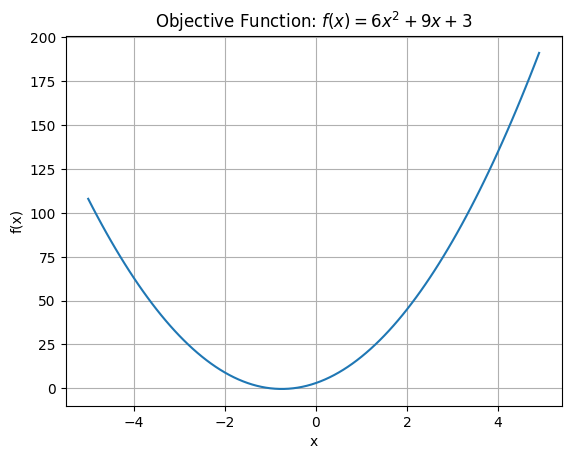

In [1]:
#@title { vertical-output: true}
import numpy as np
import matplotlib.pyplot as plt

# IMPLEMENT HERE: objective_function(x) 구현
def objective_function(x):
    return 6*x**2 + 9*x + 3

x = np.arange(-5, 5, 0.1)
y = objective_function(x)

plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Objective Function: $f(x) = 6x^2 + 9x + 3$')
plt.grid(True)
plt.show()

---
## Part 2: scipy.optimize를 이용한 최솟값 찾기 (20점)

scipy 라이브러리의 optimize.minimize 함수를 사용하여 최솟값을 찾습니다.

---

### 문제 2-1. scipy.optimize.minimize 사용 [20점]

`scipy.optimize.minimize` 함수를 사용하여 목적 함수의 최솟값을 찾습니다.

**사용법:**
```python
result = optimize.minimize(함수, 초기값)
```

**문제:** 초기값 10에서 시작하여 최솟값을 찾으세요.

**예상 결과:**
```
x: array([-0.75])
```
(최솟값의 x 좌표는 약 -0.75)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -0.37499999999997247
        x: [-7.500e-01]
      nit: 2
      jac: [ 8.941e-07]
 hess_inv: [[ 8.333e-02]]
     nfev: 8
     njev: 4


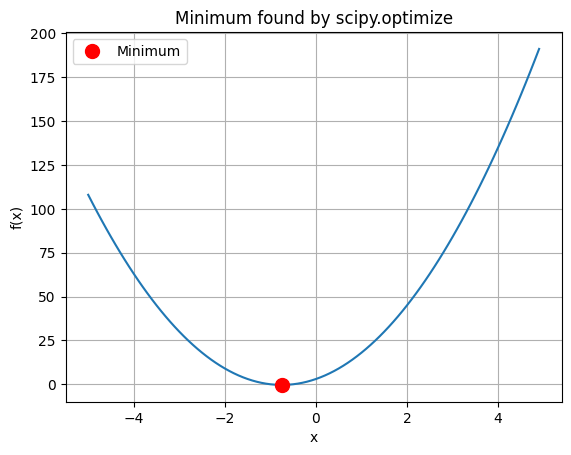

In [2]:
#@title { vertical-output: true}
from scipy import optimize

# IMPLEMENT HERE: optimize.minimize를 사용하여 최솟값 찾기
result = optimize.minimize(objective_function, 10)

print(result)

plt.plot(x, y)
plt.plot(result.x, objective_function(result.x), 'ro', markersize=10, label='Minimum')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Minimum found by scipy.optimize')
plt.legend()
plt.grid(True)
plt.show()

---
## Part 3: Gradient Descent 직접 구현 (40점)

Gradient Descent 알고리즘을 직접 구현합니다.

---

### 문제 3-1. Gradient Descent 구현 [40점]

Gradient Descent 알고리즘을 구현합니다.

**알고리즘:**
1. 그래디언트 계산: $\nabla f(x) \approx \frac{f(x + \epsilon) - f(x)}{\epsilon}$ (수치 미분)
2. 위치 업데이트: $x_{new} = x - \alpha \cdot \nabla f(x)$
3. 수렴 조건: $|\nabla f(x)| < tol$이면 종료

**파라미터:**
- `eps = 1e-8`: 수치 미분용 작은 값
- `alpha`: 학습률
- `tol`: 수렴 허용 오차
- `max_iter`: 최대 반복 횟수

**문제:** minimize 함수 내부를 구현하세요.

**예상 결과:**
```
-0.7499999...
```

In [17]:
#@title { vertical-output: true}
import numpy as np

def minimize(func, x0, tol=1e-16, max_iter=10000, alpha=0.01):
    """
    Gradient Descent를 사용하여 함수의 최솟값을 찾는 함수

    Parameters:
    - func: 최소화할 함수
    - x0: 초기값
    - tol: 수렴 허용 오차
    - max_iter: 최대 반복 횟수
    - alpha: 학습률

    Returns:
    - x: 최솟값의 위치
    """
    eps = 1e-8  # 수치 미분용 작은 값
    x = x0

    for i in range(max_iter):
        # IMPLEMENT HERE
        # 1. gradient 계산 (수치 미분 사용)
        gradient = (func(x+eps) - func(x)) / eps
        # 2. x 업데이트
        x = x - alpha * gradient
        # 3. 수렴 조건 확인 (abs(gradient) < tol이면 break)
        if(abs(gradient) < tol):
          break
        pass

    return x

찾은 최솟값의 x 좌표: -0.7500000005816787


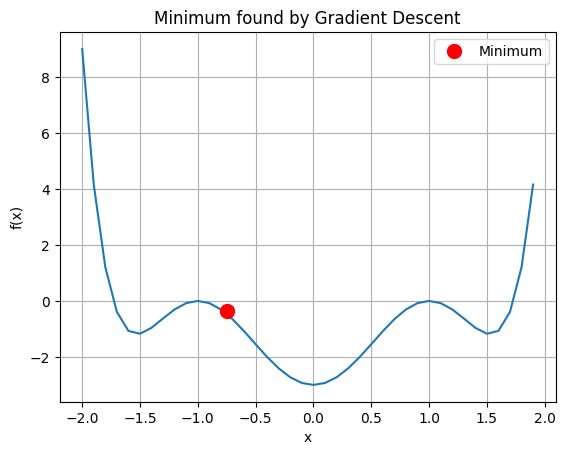

In [18]:
#@title { vertical-output: true}
# Gradient Descent 실행
result = minimize(objective_function, x0=5, alpha=0.1)
print(f"찾은 최솟값의 x 좌표: {result}")

plt.plot(x, y)
plt.plot(result, objective_function(result), 'ro', markersize=10, label='Minimum')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Minimum found by Gradient Descent')
plt.legend()
plt.grid(True)
plt.show()

---
## Part 4: Local Minima 문제 (20점)

여러 개의 극값을 가진 함수에서 Local Minima 문제를 확인합니다.

---

### 문제 4-1. Local Minima 확인 [20점]

다음 함수는 여러 개의 극솟값(local minima)을 가집니다.

$$f(x) = x^6 - 5x^4 + 7x^2 - 3$$

**문제:** 초기값 `x0 = -2`에서 시작하여 minimize 함수를 실행하고, 어느 극솟값에 도달하는지 확인하세요.

**예상 결과:** 초기값에 따라 다른 local minima에 수렴할 수 있습니다.

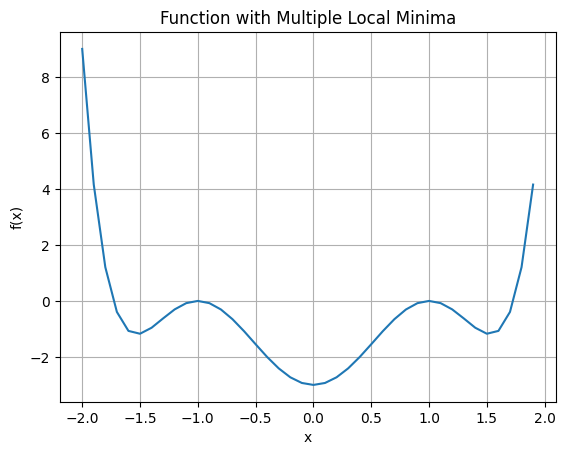

In [19]:
#@title { vertical-output: true}
import numpy as np
import matplotlib.pyplot as plt

def objective_function_2(x):
    return x**6 - 5*x**4 + 7*x**2 - 3

x = np.arange(-2, 2, 0.1)
y = objective_function_2(x)

plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Function with Multiple Local Minima')
plt.grid(True)
plt.show()

찾은 극솟값의 x 좌표: -4.732825686915021e-09
함수값: -3.0


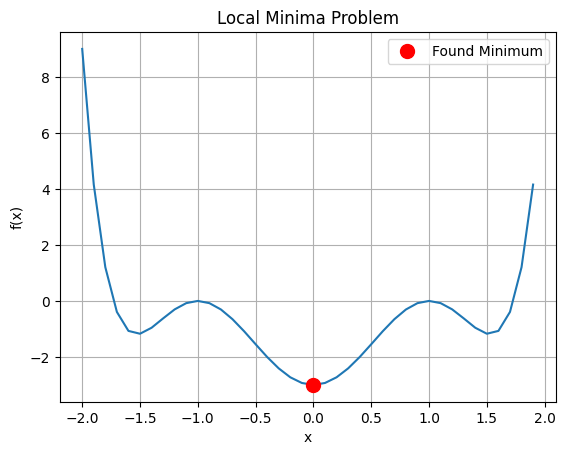

In [20]:
#@title { vertical-output: true}
# IMPLEMENT HERE: x0 = -2에서 시작하여 minimize 실행
result = minimize(objective_function_2, x0=0.5, alpha=0.01)

print(f"찾은 극솟값의 x 좌표: {result}")
print(f"함수값: {objective_function_2(result)}")

plt.plot(x, y)
plt.plot(result, objective_function_2(result), 'ro', markersize=10, label='Found Minimum')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Local Minima Problem')
plt.legend()
plt.grid(True)
plt.show()

---
## 제출 안내

1. 모든 문제를 완성한 후, 코드 셀을 실행하여 결과를 확인하세요.
2. **제출 파일:**
   - `.ipynb` 파일
   - `.pdf` 파일 (파일 > 인쇄 > PDF로 저장)
3. 파일명: `gradient_decent_학번_이름.ipynb`, `gradient_decent_학번_이름.pdf`
4. LMS에 두 파일을 함께 제출하세요.

**주의:** 기한 내에 제출하지 않으면 감점이 있습니다.

---